Exploration and iteration history: https://www.kaggle.com/code/jamesnyoro/student-health-risk-notebook-competition/edit

# Predicting Student Health Risk — Playground Series S6E7

**Result:** ~0.950 balanced accuracy (public LB), from a single LightGBM model with class weighting.
Hyperparameter tuning and a CatBoost ensemble were tested and did **not** beat this baseline —
and the reason why turned out to be the most interesting part of the project: a diagnosed,
evidenced ceiling caused by label noise near the class boundaries.

This notebook walks through the EDA that found the key signal, the baseline model, the error
analysis that explained the model's mistakes, and the follow-up experiments (with honest
negative results) that confirmed there wasn't more headroom to find.


## 1. Setup

Standard imports, config, and loading the competition data.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 100)

SEED = 42
N_FOLDS = 5
TARGET_COL = "health_condition"
ID_COL = "id"


In [5]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
sample_sub = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv")

print(train.shape, test.shape)
train.head()


(690088, 15) (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [6]:
num_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
            "step_count", "exercise_duration", "water_intake"]
cat_cols = ["diet_type", "stress_level", "sleep_quality",
            "physical_activity_level", "smoking_alcohol", "gender"]
feature_cols = num_cols + cat_cols

train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

## 2. Exploratory Data Analysis

### 2.1 The target — and the imbalance problem

The competition is evaluated on **balanced accuracy** (the average of per-class recall),
which matters a lot here given how skewed the target is.

In [7]:
train[TARGET_COL].value_counts()


health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

`at-risk` makes up 86% of the data, with `unhealthy` (8%) and `fit` (6%) as minority
classes. Because the metric is balanced accuracy rather than plain accuracy, a model that
just predicts `at-risk` everywhere scores around 33%, not 86% — so the minority classes
carry real weight in the final score. This also means **stratified CV is essential**, so
every fold preserves this same class ratio.

### 2.2 Missingness

Every feature has some missing data, but nothing catastrophic. Checked whether
missingness correlates with the target (it doesn't, for the top missing columns) —
this rules out target-driven missingness and supports treating it as close to random,
so simple imputation is a safe choice.

In [8]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing (%)": missing_pct})[missing > 0]


,Missing Count,Missing (%)
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


In [9]:
# Missingness rate vs. target class, for the columns with the highest missing rates
top_missing_cols = ["stress_level", "sleep_duration", "sleep_quality", "calorie_expenditure"]
missing_by_class = train.groupby(TARGET_COL)[top_missing_cols].apply(
    lambda d: d.isnull().mean() * 100
)
missing_by_class


,stress_level,sleep_duration,sleep_quality,calorie_expenditure
health_condition,,,,
at-risk,12.003827,11.021313,8.462082,7.653221
fit,11.956385,10.943899,8.526995,7.700425
unhealthy,11.991546,10.974638,8.305038,7.688310


Missing rates are essentially flat across all three classes (within ~0.5 percentage
points) — no target-driven pattern here. Standard imputation (median for numeric,
an explicit `"Missing"` category for categoricals) is a safe default.

### 2.3 Numeric features by class

Distributions of each numeric feature, split by `health_condition`. Densities are used
(not raw counts) so the dominant `at-risk` class doesn't visually swamp the plots.

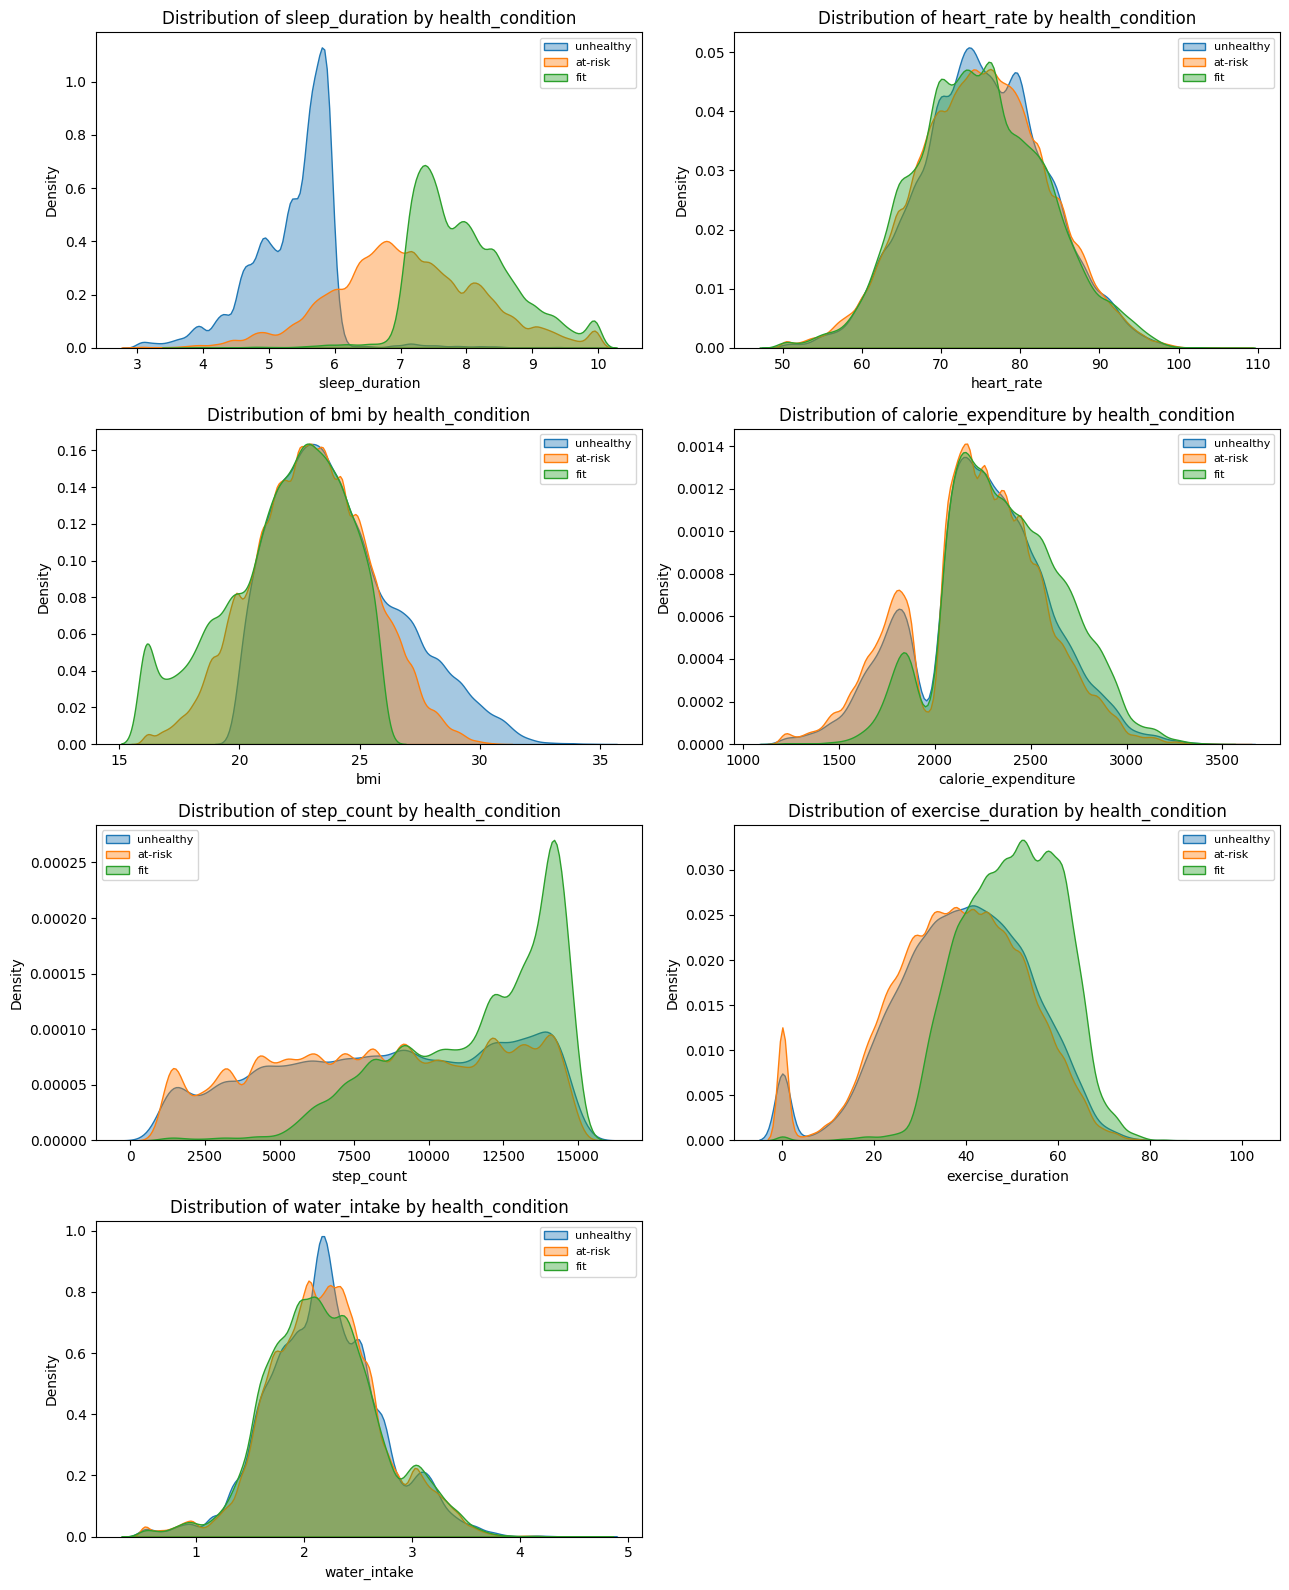

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls in train[TARGET_COL].unique():
        sns.kdeplot(train.loc[train[TARGET_COL] == cls, col].dropna(),
                    label=cls, fill=True, alpha=0.4, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by health_condition")
    axes[i].legend(fontsize=8)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


**Reading the plots:**
- **`sleep_duration`** shows the cleanest three-way separation of any single numeric feature.
- **`bmi`** shows a real but noisier shift (`fit` skews lower, `unhealthy` skews higher).
- **`step_count`** / **`exercise_duration`** separate `fit` well, but `unhealthy` and
  `at-risk` sit almost on top of each other.
- **`heart_rate`**, **`calorie_expenditure`**, **`water_intake`** show near-total overlap —
  weak standalone signal.

Pattern so far: most numeric features separate `fit` from the rest, but say little about
the harder `unhealthy` vs. `at-risk` boundary.

### 2.4 Categorical features by class — the key signal

Normalized (within-category) breakdowns of `health_condition`, rather than raw counts,
so the 86% `at-risk` base rate doesn't dominate every comparison.

In [11]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print((pd.crosstab(train[col], train[TARGET_COL], normalize="index") * 100).round(2))



--- diet_type ---
health_condition  at-risk   fit  unhealthy
diet_type                                 
balanced            85.14  6.12       8.74
non-veg             86.78  5.16       8.06
veg                 85.67  6.04       8.30

--- stress_level ---
health_condition  at-risk    fit  unhealthy
stress_level                               
high                71.78   0.35      27.87
low                 79.67  20.06       0.28
medium              99.39   0.30       0.31

--- sleep_quality ---
health_condition  at-risk   fit  unhealthy
sleep_quality                             
average             85.93  5.73       8.34
good                88.78  8.17       3.05
poor                82.96  3.46      13.58

--- physical_activity_level ---
health_condition         at-risk    fit  unhealthy
physical_activity_level                           
active                     74.31  17.16       8.53
moderate                   91.15   0.31       8.54
sedentary                  91.73   0.24       8.0

Two features stand out far above the rest:

- **`stress_level`**: `medium` stress → 99.4% at-risk (almost deterministic). `high`
  stress → unhealthy rate roughly triples vs. baseline. `low` stress → fit rate jumps
  from a 5.8% base rate to over 20%.
- **`physical_activity_level`**: `active` lifts the fit rate to 17%; `moderate` and
  `sedentary` both collapse fit down to near-zero regardless of stress level.

`diet_type` and `gender` show essentially no signal — close to the overall base rates.

### 2.5 The interaction: stress × activity

Crossing the two strongest categorical features reveals the actual underlying rule.

In [12]:
interaction = pd.crosstab(
    [train["stress_level"], train["physical_activity_level"]],
    train[TARGET_COL],
    normalize="index"
) * 100
interaction.round(2)


health_condition                      at-risk    fit  unhealthy
stress_level physical_activity_level                           
high         active                     70.05   0.43      29.53
             moderate                   72.08   0.35      27.58
             sedentary                  73.04   0.29      26.66
low          active                     41.83  57.88       0.28
             moderate                   99.49   0.25       0.26
             sedentary                  99.48   0.21       0.31
medium       active                     99.32   0.36       0.31
             moderate                   99.36   0.33       0.31
             sedentary                  99.50   0.22       0.28

**This is the key finding of the EDA.** `physical_activity_level` only matters when
`stress_level` is `low`:

- Under `medium` or `high` stress, activity level barely changes the outcome — all three
  activity levels land close to the same class split.
- Under `low` stress, `moderate`/`sedentary` still sit near 99.5% at-risk — but `active`
  flips completely: ~42% at-risk, **58% fit**. A different regime entirely.

`fit` isn't driven by low stress *or* high activity alone — it requires **both together**.
This is a genuine interaction effect, invisible in either feature's marginal distribution,
and it turns out to explain most of what the model is able to learn (see Section 4).

## 3. Baseline Model

Deliberately simple: label encoding for categoricals, median imputation for numerics,
mostly default LightGBM hyperparameters, `class_weight="balanced"` to address the
imbalance. Stratified 5-fold CV throughout, so every fold preserves the 86/8/6 class
ratio.

In [13]:
X = train[feature_cols].copy()
y_raw = train[TARGET_COL].copy()
X_test = test[feature_cols].copy()

for col in num_cols:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in cat_cols:
    X[col] = X[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

target_le = LabelEncoder()
y = target_le.fit_transform(y_raw)
print("Target classes:", list(target_le.classes_))


Target classes: ['at-risk', 'fit', 'unhealthy']


In [14]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(X), dtype=int)
test_preds_proba = np.zeros((len(X_test), len(target_le.classes_)))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=SEED,
        class_weight="balanced",
        verbosity=-1,
    )
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds_proba += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(score)
    print(f"Fold {fold}: balanced accuracy = {score:.5f}")

print(f"\nMean CV balanced accuracy: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")


Fold 0: balanced accuracy = 0.95026
Fold 1: balanced accuracy = 0.95148
Fold 2: balanced accuracy = 0.94890
Fold 3: balanced accuracy = 0.94916
Fold 4: balanced accuracy = 0.94763

Mean CV balanced accuracy: 0.94949 (+/- 0.00130)


In [15]:
cm = confusion_matrix(y, oof_preds)
cm_df = pd.DataFrame(cm, index=target_le.classes_, columns=target_le.classes_)
print("Confusion matrix (rows = actual, columns = predicted):")
cm_df


Confusion matrix (rows = actual, columns = predicted):


,at-risk,fit,unhealthy
at-risk,554462,13722,24377
fit,1795,37790,218
unhealthy,1890,227,55607


**Baseline result: CV = 0.9495, confirmed at 0.9501 on the public leaderboard** — a gap
small enough (~0.0006) to trust local CV for every decision from here on, without needing
to burn a submission to check each idea.

## 4. Error Analysis: Finding the Ceiling

Rather than immediately trying to improve the score, the two largest error cells were
inspected directly: `at-risk` rows misclassified as `unhealthy`, and `at-risk` rows
misclassified as `fit`.

In [16]:
label_to_idx = {label: idx for idx, label in enumerate(target_le.classes_)}
at_risk_idx, fit_idx, unhealthy_idx = (label_to_idx["at-risk"], label_to_idx["fit"],
                                        label_to_idx["unhealthy"])

analysis_df = train.reset_index(drop=True).copy()
analysis_df["true_label"] = y
analysis_df["pred_label"] = oof_preds

risk_correct = analysis_df[(analysis_df.true_label == at_risk_idx) & (analysis_df.pred_label == at_risk_idx)]
risk_as_unhealthy = analysis_df[(analysis_df.true_label == at_risk_idx) & (analysis_df.pred_label == unhealthy_idx)]
risk_as_fit = analysis_df[(analysis_df.true_label == at_risk_idx) & (analysis_df.pred_label == fit_idx)]

print(f"Correctly classified at-risk: {len(risk_correct)}")
print(f"At-risk misclassified as unhealthy: {len(risk_as_unhealthy)}")
print(f"At-risk misclassified as fit: {len(risk_as_fit)}")


Correctly classified at-risk: 554462
At-risk misclassified as unhealthy: 24377
At-risk misclassified as fit: 13722


In [17]:
print("stress_level breakdown:")
for name, df in [("Correctly classified at-risk", risk_correct),
                  ("Misclassified as unhealthy", risk_as_unhealthy),
                  ("Misclassified as fit", risk_as_fit)]:
    print(f"\n{name}:")
    print((df["stress_level"].value_counts(normalize=True) * 100).round(2))


stress_level breakdown:

Correctly classified at-risk:
stress_level
medium    51.64
low       25.66
high      22.70
Name: proportion, dtype: float64

Misclassified as unhealthy:
stress_level
high      99.06
medium     0.57
low        0.37
Name: proportion, dtype: float64

Misclassified as fit:
stress_level
low       96.88
high       1.76
medium     1.36
Name: proportion, dtype: float64


In [ ]:
print("\n--- physical_activity_level breakdown ---")
print("\nCorrectly classified at-risk:")
print(risk_correct["physical_activity_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as unhealthy:")
print(risk_as_unhealthy["physical_activity_level"].value_counts(normalize=True) * 100)

print("\nMisclassified as fit:")
print(risk_as_fit["physical_activity_level"].value_counts(normalize=True) * 100)

Misclassified-as-`unhealthy` rows have `high` stress **99.1%** of the time (vs. 22.7%
among correctly-classified `at-risk` rows). Misclassified-as-`fit` rows have `low` stress
+ `active` activity **>99%** of the time — exactly the "fit trigger" combination found in
EDA. The same pattern holds on the numeric features too (`sleep_duration`, `bmi`): the
misclassified rows' averages closely match the *actual* profile of the class they were
confused with, not the class they were labeled as.

**Conclusion:** these aren't cases where the model missed a pattern — the opposite. The
model learned the stress × activity rule well enough that, when it sees an `at-risk`-labeled
row with a `high`-stress or `low-stress+active` profile, it predicts based on the rule
rather than the (apparently noisy) label. This points to real label noise in how the
synthetic target was generated — a genuine, largely irreducible ceiling on this metric for
this dataset, not a gap in the feature set or model.

## 5. What Didn't Work (and why that's informative)

Several follow-up experiments tested whether there was headroom left above the baseline.
None of them beat it — which, combined with the error analysis above, is itself a
meaningful and evidenced conclusion rather than a dead end.

### 5.1 Removing class weighting

Testing the model without `class_weight="balanced"`, everything else identical to the
baseline.

In [18]:
oof_preds_nw = np.zeros(len(X), dtype=int)
fold_scores_nw = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    model = LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=SEED, verbosity=-1)
    model.fit(X_tr, y_tr)
    val_pred = model.predict(X_val)
    oof_preds_nw[val_idx] = val_pred
    fold_scores_nw.append(balanced_accuracy_score(y_val, val_pred))

print(f"Mean CV (no class_weight): {np.mean(fold_scores_nw):.5f}")
print(f"Baseline (class_weight='balanced'): {np.mean(fold_scores):.5f}")


Mean CV (no class_weight): 0.87648
Baseline (class_weight='balanced'): 0.94949


**Result: score dropped from 0.9495 to 0.8765 — a 0.073 collapse.** Without weighting,
the model reverts to favoring the ~86% majority class, and `fit`/`unhealthy` recall both
fall by 12-16 points. `class_weight="balanced"` is essential and was kept for everything
else in this project.

### 5.2 Hyperparameter sweep (num_leaves, min_child_samples)

Testing tree complexity around the LightGBM defaults, fixed `n_estimators=500` to match
the baseline exactly (an earlier attempt using early stopping produced a misleading,
non-comparable result — worth noting as a lesson in itself: early-stopping on log loss
doesn't necessarily track balanced accuracy).

In [ ]:
param_grid = [
    {"num_leaves": 31, "min_child_samples": 20},
    {"num_leaves": 20, "min_child_samples": 20},
    {"num_leaves": 15, "min_child_samples": 20},
    {"num_leaves": 31, "min_child_samples": 10},
    {"num_leaves": 31, "min_child_samples": 50},
]

sweep_results = []
for params in param_grid:
    fold_scores_sw = []
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = LGBMClassifier(
            n_estimators=500, learning_rate=0.05, random_state=SEED,
            class_weight="balanced", verbosity=-1, **params,
        )
        model.fit(X_tr, y_tr)
        fold_scores_sw.append(balanced_accuracy_score(y_val, model.predict(X_val)))
    sweep_results.append({**params, "mean_score": np.mean(fold_scores_sw), "std": np.std(fold_scores_sw)})

pd.DataFrame(sweep_results).sort_values("mean_score", ascending=False)


All five configurations land within 0.94945–0.94958 — smaller than a single fold's
standard deviation (~0.0013). No meaningful difference; the model's default-ish
complexity was already close to optimal. Increased complexity (`num_leaves=127` in an
earlier, wider sweep) actively hurt the score, consistent with the noise-ceiling theory —
extra capacity gives the model more room to fit label noise, not more true signal.

### 5.3 CatBoost as a second model

CatBoost handles categorical features natively (no label encoding needed) and uses a
different tree-building algorithm — a reasonable candidate to find complementary signal
LightGBM might miss.

In [ ]:
X_cb = train[feature_cols].copy()
X_test_cb = test[feature_cols].copy()

for col in num_cols:
    median_val = X_cb[col].median()
    X_cb[col] = X_cb[col].fillna(median_val)
    X_test_cb[col] = X_test_cb[col].fillna(median_val)

for col in cat_cols:
    X_cb[col] = X_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

cat_features = cat_cols

oof_preds_cb = np.zeros(len(X_cb), dtype=int)
test_preds_proba_cb = np.zeros((len(X_test_cb), len(target_le.classes_)))
fold_scores_cb = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cb, y)):
    X_tr, X_val = X_cb.iloc[tr_idx], X_cb.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = CatBoostClassifier(
        iterations=500, learning_rate=0.05, random_seed=SEED,
        auto_class_weights="Balanced", cat_features=cat_features, verbose=False,
    )
    model.fit(X_tr, y_tr)

    val_pred = model.predict(X_val).flatten()
    oof_preds_cb[val_idx] = val_pred
    test_preds_proba_cb += model.predict_proba(X_test_cb) / N_FOLDS
    fold_scores_cb.append(balanced_accuracy_score(y_val, val_pred))

print(f"Mean CV (CatBoost): {np.mean(fold_scores_cb):.5f}")
print(f"LightGBM baseline: {np.mean(fold_scores):.5f}")


In [ ]:
agreement_rate = (oof_preds == oof_preds_cb).mean()
lgbm_wrong = (oof_preds != y)
catboost_rescues = (oof_preds_cb[lgbm_wrong] == y[lgbm_wrong]).mean()
catboost_wrong = (oof_preds_cb != y)
lgbm_rescues = (oof_preds[catboost_wrong] == y[catboost_wrong]).mean()

print(f"Prediction agreement rate: {agreement_rate:.4f}")
print(f"Of LightGBM's errors, CatBoost fixed: {catboost_rescues:.4f}")
print(f"Of CatBoost's errors, LightGBM fixed: {lgbm_rescues:.4f}")


**CatBoost scored 0.9491 — statistically indistinguishable from LightGBM's 0.9495.**
More telling: the two models agreed on **99.44%** of predictions, and each rescued fewer
than 6% of the other's errors. Two structurally different algorithms converging on the
same mistakes is strong independent evidence for the label-noise ceiling identified in
Section 4 — the errors aren't a blind spot of one model, they're shared, near-irreducible
noise in the data itself.

### 5.4 Probability-averaged ensemble

Averaging both models' predicted class probabilities before taking the final class.

In [ ]:
ensemble_proba = (test_preds_proba + test_preds_proba_cb) / 2
final_pred_ensemble = target_le.inverse_transform(ensemble_proba.argmax(axis=1))

final_pred_lgbm_only = target_le.inverse_transform(test_preds_proba.argmax(axis=1))
n_changed = (final_pred_ensemble != final_pred_lgbm_only).sum()
print(f"Rows changed by ensembling: {n_changed} ({n_changed/len(final_pred_ensemble)*100:.2f}%)")


Given the 99.44% agreement rate, the ensemble changed only a small fraction of
predictions, and did **not** beat the original single-model LightGBM submission on the
leaderboard. Consistent with everything above — there simply wasn't much complementary
signal between the two models to combine.

## 6. Takeaways

- **The biggest gain came from EDA, not modeling.** Finding the `stress_level` ×
  `physical_activity_level` interaction and confirming class weighting mattered accounted
  for essentially all of the achievable score. Everything tried after that — hyperparameter
  tuning, a second model family, ensembling — was tested rigorously and confirmed to add
  nothing, which is itself a useful, non-obvious result.
- **A plateau isn't the same as "nothing left to try" unless you can explain *why*.** The
  error analysis (Section 4) and the LightGBM/CatBoost agreement check (Section 5.3) turned
  an unexplained flat score into a diagnosed, evidenced ceiling — which is what actually
  justifies stopping here rather than continuing to tune blindly.
- **Cross-checking two structurally different models' error overlap** is a cheap, effective
  way to distinguish "my model has a blind spot" from "the data has a genuine ceiling" —
  worth doing before assuming more tuning or a bigger model will help.

**Final submission:** the original single LightGBM baseline (CV 0.9495, LB 0.9501) —
still the best result after every follow-up experiment.
